In [1]:
import numpy as np
import pandas as pd
from epiweeks import Week
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from ensemble import compute_ensemble
from harmonize_preds import aux_functions


In [72]:
import matplotlib as mpl 

mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12


Load preds: 

In [2]:
df_for = pd.read_csv('predictions/forecasts_2nd_sprint_update.csv.gz')
df_for.date = pd.to_datetime(df_for.date)
df_for = df_for.loc[df_for.model_id != 137]
df_for.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id,state
0,2025-10-05,0.0,0.0,0.0,101.922668,356.781097,790.528656,1992.101929,2496.932953,2749.348465,133,DF
1,2025-10-12,0.0,0.0,0.0,74.657440,267.429688,815.399750,2309.984863,2940.143433,3255.222717,133,DF
2,2025-10-19,0.0,0.0,0.0,4.947113,197.892944,957.998810,2695.268555,3423.885498,3788.193970,133,DF
3,2025-10-26,0.0,0.0,0.0,38.830750,305.259369,1268.370544,3319.793701,4166.516785,4589.878326,133,DF
4,2025-11-02,0.0,0.0,0.0,22.203766,362.994873,1516.120422,3958.920898,4977.201721,5486.342133,133,DF


In [3]:
df_for.model_id.unique().shape

(15,)

Load metrics: 

In [4]:
df_m_norm = pd.read_csv('results/metrics_wis_norm.csv.gz')

df_m_norm.head()

,model,state,validation_test,WIS
0,108,PA,1,0.306515
1,158,PA,1,0.235720
2,133,PA,1,0.178181
3,144,PA,1,0.162322
4,152,PA,1,0.628968


In [5]:
df_m_norm.loc[df_m_norm.model == 137]

,model,state,validation_test,WIS


In [6]:
df_m_norm.model.unique().shape

(15,)

In [7]:
n_models = 5
best_models = {}

for state in df_m_norm.state.unique():

    best_models[f'{state}'] = df_m_norm.loc[(df_m_norm.state == state)].groupby(['state', 'model'])[['WIS']].mean().reset_index().sort_values(by = 'WIS').model.values[:n_models]


In [8]:
best_models['PR']

array([136, 144, 155, 154, 150])

Ensemble of the median of the models:

In [9]:
dfm_top = pd.DataFrame()

for st in df_for.state.unique(): 
    df_median_ens = compute_ensemble(df_for.loc[(df_for.state == st) &
                                                  (df_for.model_id.isin(best_models[st]))])
    df_median_ens.head()

    dfm_top = pd.concat([dfm_top, df_median_ens], ignore_index = True)

dfm_top['model_id'] = 'E_median_top'

dfm_top.head()

,date,state,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id
0,2025-10-05,DF,1.0,2.0,4.0,9.0,36.316665,86.010745,157.0,257.874179,398.000000,E_median_top
1,2025-10-12,DF,2.0,2.0,4.0,10.0,34.649051,94.248957,196.0,292.000000,405.445650,E_median_top
2,2025-10-19,DF,2.0,3.0,5.0,12.0,35.146760,90.000000,180.0,283.101775,421.337491,E_median_top
3,2025-10-26,DF,2.0,3.0,6.0,14.0,40.399247,104.193800,205.0,286.000000,435.649320,E_median_top
4,2025-11-02,DF,3.0,4.0,7.0,16.0,63.000000,129.745682,270.0,358.107097,500.000000,E_median_top


In [10]:
dfm_top.state.value_counts()

state
DF    53
MA    53
PR    53
AL    53
TO    53
RN    53
AC    53
RR    53
PB    53
SE    53
AP    53
MS    53
CE    53
RO    53
PI    53
RS    53
GO    53
BA    53
SP    53
MG    53
PA    53
MT    53
SC    53
AM    53
RJ    53
PE    53
ES    53
Name: count, dtype: int64

## Cumulative cases

### Just sum the percentis

In [11]:
df_cum_1 = dfm_top.groupby(['model_id', 'state'])[['lower_90', 'pred', 'upper_90']].sum().reset_index()

df_cum_1.head()

,model_id,state,lower_90,pred,upper_90
0,E_median_top,AC,1169.135974,7100.670135,29015.806248
1,E_median_top,AL,2019.392103,9881.062198,40066.286620
2,E_median_top,AM,1527.384425,6098.853772,18919.880729
3,E_median_top,AP,53.000000,1411.489012,8002.151084
4,E_median_top,BA,18526.853153,38718.180296,86109.691402


### Get log normal aproximation of the preds and apply the Davi method:

In [12]:
l_pos = tuple([col for col in df_median_ens.columns if 'lower' in col])
u_pos = tuple([col for col in df_median_ens.columns if 'upper' in col])
the_pos = list(l_pos + u_pos)
l_pos = list(l_pos)
u_pos = list(u_pos)

lvls = (0.5, 0.8, 0.9, 0.95)
p = [aux_functions.quantile_pair(lvl) for lvl in lvls]
p = [i for quantile in p for i in quantile]
p.append(0.5)
ps = p.copy()
ps.sort()

In [13]:
def process_row(row):
    '''
    Estimate the lognormal parameters for each row in the dataframe
    '''
    #the_pos =  [ 'upper_50', 'upper_80', 'upper_90', 'upper_95']

    #ps = [0.5, 0.75,0.9,0.95, 0.975]
    # pegar valores da linha
    xi_values = list(row[the_pos].values) if hasattr(row[the_pos], "values") else [row[the_pos]]
    xi_values.append(row["pred"])
    
    # ordenar
    xi_sorted = sorted(xi_values)

    out = pd.DataFrame({
    'p': ps,
    'xi': xi_sorted
    })

    out = out.loc[out.xi > 0]
    # ajustar CDF (aqui você precisa garantir que 'out' está definido de fora
    cdf_fit = aux_functions.fit_ln_CDF(
        x=out["xi"],
        Fhat=out["p"],
        weighting=1
    )
    
    return cdf_fit

In [15]:
%%time 

dfm_top[['mu', 'sigma']] = dfm_top.apply(process_row, axis=1, result_type = 'expand')

dfm_top.head()

CPU times: user 36.9 s, sys: 185 ms, total: 37 s
Wall time: 37.4 s


,date,state,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id,mu,sigma
0,2025-10-05,DF,1.0,2.0,4.0,9.0,36.316665,86.010745,157.0,257.874179,398.000000,E_median_top,3.108446,1.468397
1,2025-10-12,DF,2.0,2.0,4.0,10.0,34.649051,94.248957,196.0,292.000000,405.445650,E_median_top,3.349067,1.355086
2,2025-10-19,DF,2.0,3.0,5.0,12.0,35.146760,90.000000,180.0,283.101775,421.337491,E_median_top,3.368291,1.364894
3,2025-10-26,DF,2.0,3.0,6.0,14.0,40.399247,104.193800,205.0,286.000000,435.649320,E_median_top,3.384992,1.373416
4,2025-11-02,DF,3.0,4.0,7.0,16.0,63.000000,129.745682,270.0,358.107097,500.000000,E_median_top,3.656610,1.305125


Error of the median and upper_90 aproximation: 

In [17]:
from sklearn.metrics import root_mean_squared_error as rmse

In [16]:
df_median_ens = dfm_top

In [18]:
df_median_ens[f'lower_90_apx'] = lognorm.ppf(0.05, scale=np.exp(df_median_ens[f'mu'].values), s=df_median_ens[f'sigma'].values)
df_median_ens[f'med_apx'] = lognorm.ppf(0.5, scale=np.exp(df_median_ens[f'mu'].values), s=df_median_ens[f'sigma'].values)
df_median_ens[f'upper_90_apx'] = lognorm.ppf(0.95, scale=np.exp(df_median_ens[f'mu'].values), s=df_median_ens[f'sigma'].values)


compute the rmse: 

In [19]:
df_erros = pd.DataFrame()

for state in  df_median_ens['state'].unique():

    try: 
        df_model = df_median_ens.loc[(df_median_ens.state == state)]
    
        df_erros = pd.concat([df_erros,
                             pd.DataFrame([[state, 
                                            rmse(df_model.lower_90, df_model.lower_90_apx),
                                            rmse(df_model.pred, df_model.med_apx), 
                                            rmse(df_model.upper_90, df_model.upper_90_apx)]],
                                         columns = ['state', 'rmse_lower_apx', 'rmse_pred_apx', 'rmse_upper_apx',])],
                            ignore_index = True)
    except: 
        pass 

df_erros['sum_erros'] =  df_erros['rmse_lower_apx'] + df_erros['rmse_pred_apx'] + df_erros['rmse_upper_apx']
df_erros.head()

,state,rmse_lower_apx,rmse_pred_apx,rmse_upper_apx,sum_erros
0,DF,3.817607,154.509450,243.125596,401.452653
1,PI,4.191212,28.418114,15.691343,48.300669
2,PE,6.470866,77.417478,132.299873,216.188217
3,RJ,8.074461,353.848197,757.032867,1118.955526
4,AM,0.967271,24.593951,27.042886,52.604108


In [20]:
df_erros.sort_values(by = 'sum_erros', ascending= False).head(2)

,state,rmse_lower_apx,rmse_pred_apx,rmse_upper_apx,sum_erros
8,MG,328.85690,2433.225833,3296.228814,6058.311547
9,SP,455.74574,3590.089002,1643.917560,5689.752302


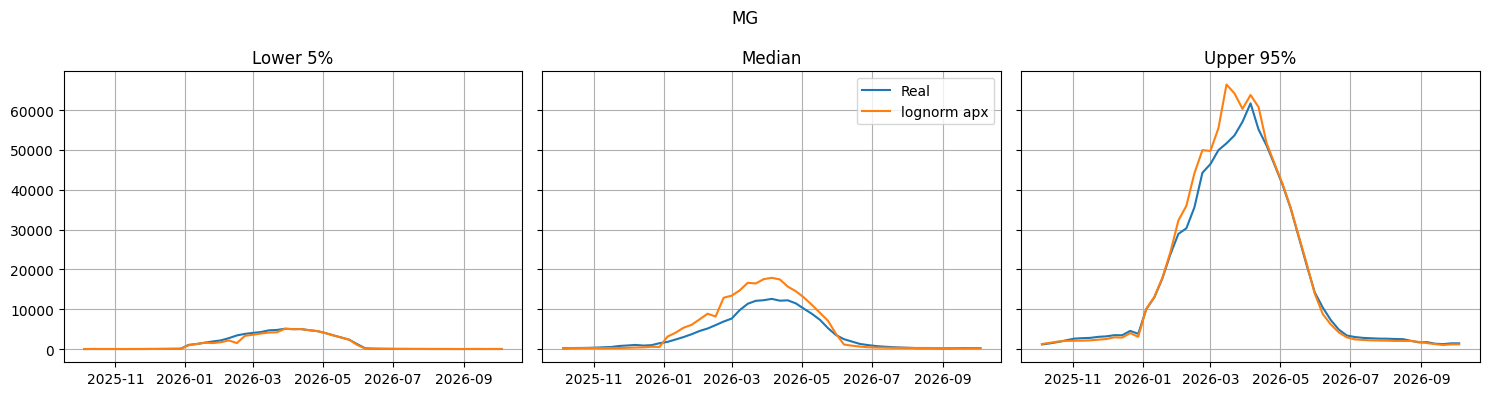

In [21]:
state = 'MG'

df_problem = df_median_ens.loc[df_median_ens.state == state]

_, ax = plt.subplots(1,3, figsize = (15, 4), sharey = True)

ax[0].plot(df_problem.date, df_problem.lower_90 )
    
ax[0].plot(df_problem.date, df_problem.lower_90_apx, label = 'lognorm apx')
        
ax[0].set_title('Lower 5%')

ax[1].plot(df_problem.date, df_problem.pred, label = 'Real')
    
ax[1].plot(df_problem.date, df_problem.med_apx, label = 'lognorm apx')
    
ax[1].set_title('Median')
    
ax[1].legend()
    
ax[2].plot(df_problem.date, df_problem.upper_90 )
    
ax[2].plot(df_problem.date, df_problem.upper_90_apx, label = 'lognorm apx')
        
ax[2].set_title('Upper 95%')
    
plt.suptitle(f'{state}')

for ax_ in ax.ravel():

    ax_.grid()
    
plt.tight_layout()


In [22]:
import polars as pl
import scipy.stats as st
from tqdm import tqdm

In [23]:
df_median_ens.state.unique()

array(['DF', 'PI', 'PE', 'RJ', 'AM', 'SC', 'MT', 'PA', 'MG', 'SP', 'BA',
       'GO', 'RS', 'RO', 'MA', 'CE', 'MS', 'AP', 'SE', 'PB', 'RR', 'AC',
       'RN', 'TO', 'AL', 'PR', 'ES'], dtype=object)

In [24]:
dengue = pl.read_csv('/Users/eduardoaraujo/Desktop/ensemble_MLP/dengue_agg.csv.gz')
dengue = dengue.rename({'uf': 'state'})
#dengue = dengue.with_columns(
#    np.log1p(pl.col('casos')).alias('log_casos')
#)
#dengue = dengue.filter(
#    pl.col('state') != 'ES',
#)[['state','date','casos']]
dengue = dengue[['state','date','casos']]

dengue = dengue.with_columns(
    pl.col("date").str.strptime(pl.Date, format="%Y-%m-%d").alias("date")
)

dengue = dengue.with_columns(pl.col('date').dt.year().alias('year'))

dengue


state,date,casos,year
str,date,i64,i32
"""AC""",2010-01-03,760,2010
"""TO""",2010-01-03,231,2010
"""SP""",2010-01-03,1628,2010
"""SE""",2010-01-03,3,2010
"""SC""",2010-01-03,10,2010
…,…,…,…
"""AL""",2025-07-27,54,2025
"""AC""",2025-07-27,27,2025
"""SP""",2025-07-27,843,2025


In [25]:
F_marginals = pl.from_pandas(df_median_ens[['date', 
                                            'state',
                                            'mu','sigma']].sort_values(by ='date'))


F_marginals


date,state,mu,sigma
datetime[ns],str,f64,f64
2025-10-05 00:00:00,"""DF""",3.108446,1.468397
2025-10-05 00:00:00,"""AP""",2.345674,1.196794
2025-10-05 00:00:00,"""ES""",3.1336,1.598805
2025-10-05 00:00:00,"""PI""",2.758246,0.698425
2025-10-05 00:00:00,"""BA""",5.333466,0.541453
…,…,…,…
2026-10-04 00:00:00,"""RR""",1.168347,1.358979
2026-10-04 00:00:00,"""RJ""",4.592079,1.119501
2026-10-04 00:00:00,"""RS""",3.154959,1.609703


In [26]:
def estimate_rho_correlation(history):
    ranks = st.rankdata(history) / (len(history) + 1)
    u = ranks
    z = st.norm.ppf(u)  # Gaussian scores

    # lagged pairs
    z_lag, z_curr = z[:-1], z[1:]
    rho = np.corrcoef(z_lag, z_curr)[0, 1]
    return rho

In [27]:
rhos = []
states = np.sort(dengue['state'].unique())
for state in states:
    history = dengue.filter(pl.col('state') == state).sort('date')['casos']
    rho = estimate_rho_correlation(history)
    rhos.append(rho)

rhos = pl.DataFrame({'state': states, 'rho': rhos})

In [28]:
rhos

state,rho
str,f64
"""AC""",0.945004
"""AL""",0.96378
"""AM""",0.92289
"""AP""",0.917369
"""BA""",0.966292
…,…
"""RS""",0.904208
"""SC""",0.912145
"""SE""",0.927776


In [29]:
def sample_path(forecast_marginals, rho, random_state=None):
    horizon = len(forecast_marginals)
    rng = np.random.default_rng(random_state)
    path = np.zeros(horizon)
    x_0 = forecast_marginals[0].rvs(size=1, random_state=rng)[0]
    path[0] = x_0
    for j in range(1, horizon):
        u_prev = forecast_marginals[j-1].cdf(path[j-1])
        z_prev = st.norm.ppf(u_prev)
        z = rng.normal(loc=rho * z_prev, scale=np.sqrt(1 - rho**2))
        u = st.norm.cdf(z)
        x = forecast_marginals[j].ppf(u)
        path[j] = x
    return path

def cumulative_estimation(forecast_marginals, rho, n_paths=1000):
    paths = [sample_path(forecast_marginals, rho) for _ in range(n_paths)]
    samples = [sum(p) for p in paths]
    return list(np.percentile(samples, [5, 50, 95]))



In [30]:
states = rhos.sort('state')['state'].unique()
models = ["E_median_all"]
results = []

for state in tqdm(states, desc="States"):
    for model in tqdm(models, desc=f"Models for {state}", leave=False):
        rho = rhos.filter(pl.col('state') == state)['rho'].to_numpy()[0]
        forecast_marginals = []
        for row in F_marginals.filter(pl.col('state') == state).iter_rows(named=True):
            mu, sigma = row['mu'], row['sigma']
            forecast_marginals.append(st.lognorm(s=sigma, scale=np.exp(mu)))
        cumu = cumulative_estimation(forecast_marginals, rho, n_paths=2000)
        results.append({
            'state': state,
            'model': model.split('_')[1],
            'lower_90': cumu[0],
            'pred': cumu[1],
            'upper_90': cumu[2],
            'rho': rho
        })

results = pl.DataFrame(results)

States: 100%|██████████| 27/27 [06:58<00:00, 15.48s/it]


In [31]:
results

state,model,lower_90,pred,upper_90,rho
str,str,f64,f64,f64,f64
"""TO""","""median""",3194.116272,7922.752429,18934.647668,0.9589
"""CE""","""median""",3423.43336,11075.564487,34799.613839,0.972429
"""MA""","""median""",2225.773092,5337.29099,13289.554109,0.937879
"""ES""","""median""",4690.844476,25847.003299,155411.714458,0.984694
"""AL""","""median""",3147.984002,10466.535887,33427.584497,0.96378
…,…,…,…,…,…
"""PA""","""median""",5454.487042,10375.813919,19623.665706,0.943659
"""PE""","""median""",6028.525379,18732.424609,56846.171419,0.966105
"""RR""","""median""",143.188167,445.832783,1345.28601,0.891562


In [32]:
df_cum_cop = results.to_pandas()
df_cum_cop.head()

,state,model,lower_90,pred,upper_90,rho
0,TO,median,3194.116272,7922.752429,18934.647668,0.958900
1,CE,median,3423.433360,11075.564487,34799.613839,0.972429
2,MA,median,2225.773092,5337.290990,13289.554109,0.937879
3,ES,median,4690.844476,25847.003299,155411.714458,0.984694
4,AL,median,3147.984002,10466.535887,33427.584497,0.963780


Plot the cumulative cases: 

In [33]:
df_cum_1.head()

,model_id,state,lower_90,pred,upper_90
0,E_median_top,AC,1169.135974,7100.670135,29015.806248
1,E_median_top,AL,2019.392103,9881.062198,40066.286620
2,E_median_top,AM,1527.384425,6098.853772,18919.880729
3,E_median_top,AP,53.000000,1411.489012,8002.151084
4,E_median_top,BA,18526.853153,38718.180296,86109.691402


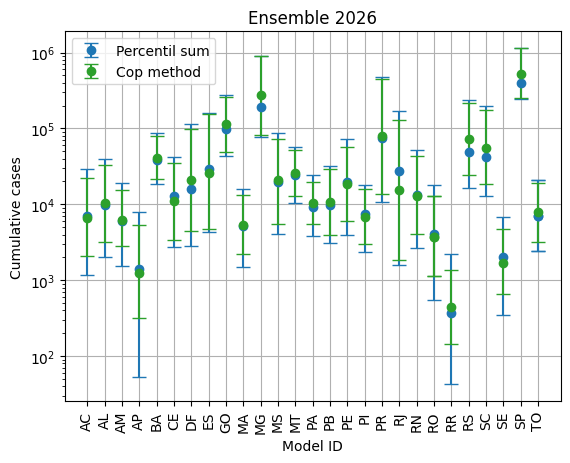

In [34]:
#obs = df_cum.casos.values[0]
_, ax = plt.subplots()

#ax.axhline(obs, color = 'black', linewidth =2, linestyle = '--', label = 'Data')

# Somando os percentis   
x = df_cum_1.state.astype(str)
y = df_cum_1.pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_1.lower_90, df_cum_1.upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_1.lower_90, df_cum_1.upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='tab:blue', ecolor='tab:blue', capsize=5)
        
ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='tab:blue', ecolor='tab:blue', capsize=5, label = 'Percentil sum')


# método da cópula
x = df_cum_cop.state.astype(str)
y = df_cum_cop.pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_cop.lower_90, df_cum_cop.upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_cop.lower_90, df_cum_cop.upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='tab:green', ecolor='tab:green', capsize=5)
        
ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='tab:green', ecolor='tab:green', capsize=5, label = 'Cop method')


ax.set_ylabel('Cumulative cases')
ax.set_xlabel('Model ID')
    
ax.set_title(f'Ensemble 2026')

#    ax.set_ylim([0, max(2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 1)].casos.values[0],
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 2)].casos.values[0], 
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 3)].casos.values[0])])
ax.set_yscale('log')
ax.grid()
ax.legend()
for label in ax.get_xticklabels():
        label.set_rotation(90)


Figura final: 

In [35]:
order = ['PR', 'SC', 'RS','SP', 'MG', 'RJ', 'ES', 
         'DF', 'MT', 'MS', 'GO', 'BA', 'CE', 'PE',
        'PB', 'PI', 'RN', 'MA', 'AL', 'SE',
         'RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO' ]

df_cum_cop['state'] = pd.Categorical(df_cum_cop['state'],
                                     categories = order,
                                     ordered = True)

df_cum_cop = df_cum_cop.sort_values(by = 'state')

df_cum_cop.head()

,state,model,lower_90,pred,upper_90,rho
15,PR,median,13770.616942,79983.896118,4.538979e+05,0.979600
21,SC,median,18322.588087,54613.057867,1.753233e+05,0.912145
25,RS,median,24064.235870,73406.115104,2.183210e+05,0.904208
8,SP,median,251444.387413,520739.987410,1.141495e+06,0.985772
7,MG,median,83020.202900,279047.044148,8.888152e+05,0.971145


In [37]:
df_d = dengue.to_pandas()
df_d = df_d.loc[df_d.date >= pd.to_datetime(Week(2024, 41).startdate())]
df_d = df_d.groupby('state')[['casos']].sum().reset_index()

df_d['state'] = pd.Categorical(df_d['state'],
                                     categories = order,
                                     ordered = True)

df_d = df_d.sort_values(by = 'state')

df_d.head()

,state,casos
17,PR,120216
23,SC,33012
22,RS,88884
25,SP,968247
10,MG,182216


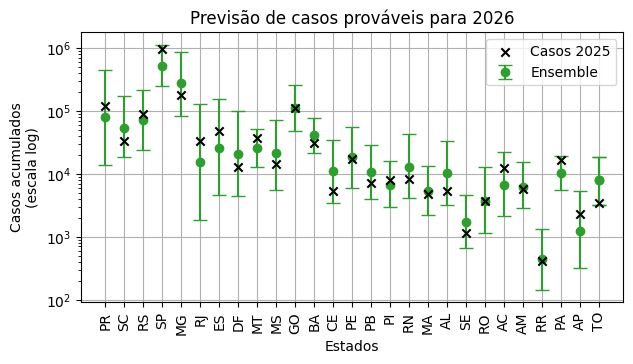

In [39]:
_, ax = plt.subplots(figsize = (7, 3.5))

#ax.axhline(obs, color = 'black', linewidth =2, linestyle = '--', label = 'Data')
ax.scatter(df_d.state, df_d.casos, marker = 'x',color = 'black', label = 'Casos 2025', zorder = 3)
# método da cópula
x = df_cum_cop.state.astype(str)
y = df_cum_cop.pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_cop.lower_90, df_cum_cop.upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_cop.lower_90, df_cum_cop.upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='tab:green', ecolor='tab:green', capsize=5)
        
ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='tab:green', ecolor='tab:green', capsize=5, label = 'Ensemble')


ax.set_ylabel('Casos acumulados\n(escala log)')
ax.set_xlabel('Estados')
    
ax.set_title(f'Previsão de casos prováveis para 2026')

#    ax.set_ylim([0, max(2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 1)].casos.values[0],
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 2)].casos.values[0], 
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 3)].casos.values[0])])
ax.set_yscale('log')
ax.grid()
ax.legend()
for label in ax.get_xticklabels():
        label.set_rotation(90)

plt.savefig('figures/ens_median_2026.png', dpi = 400, bbox_inches = 'tight')

In [40]:
df_median_ens.to_csv('predictions/ensemble_median_2026.csv.gz', index = False)

In [ ]:
df_cum_cop.to_csv('predictions/ensemble_median_2026_cum_cases.csv.gz', index = False)

### Compute the cumulative cases for the best model in the period:

In [43]:
df_best_st_model = df_m_norm.loc[df_m_norm.groupby("state")["WIS"].idxmin()][['model', 'state']].rename(columns = {'model':'model_id'})
df_best_st_model.head()

,model_id,state
1058,157,AC
1004,156,AL
925,150,AM
964,158,AP
875,133,BA


In [46]:
tuples_to_keep = tuples = list(df_best_st_model[['model_id', 'state']].itertuples(index=False, name=None))

df_for_best = df_for[df_for[['model_id', 'state']].apply(tuple, axis=1).isin(tuples_to_keep)]

df_for_best.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,model_id,state
530,2025-10-05,50.027145,63.182831,89.494202,160.155823,224.615051,311.252869,390.380371,418.670563,432.815659,133,BA
531,2025-10-12,23.468094,37.739227,66.281494,142.818329,208.706909,284.653656,355.437134,381.224152,394.117661,133,BA
532,2025-10-19,31.541794,46.095123,75.201782,151.629944,221.370544,293.127441,365.770264,391.559570,404.454224,133,BA
533,2025-10-26,43.725052,58.213409,87.190125,163.521301,229.057434,299.780670,380.521851,410.469025,425.442612,133,BA
534,2025-11-02,56.218857,70.321136,98.525696,174.456573,239.260010,300.167358,377.810608,407.553833,422.425446,133,BA


Aplicar o método da cúpula para acumular os casos: 

get the lognormal parameters:

In [48]:
df_for_best[['mu', 'sigma']] = df_for_best.apply(process_row, axis=1, result_type = 'expand')


/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_66792/4271899542.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_best[['mu', 'sigma']] = df_for_best.apply(process_row, axis=1, result_type = 'expand')
/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_66792/4271899542.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_best[['mu', 'sigma']] = df_for_best.apply(process_row, axis=1, result_type = 'expand')


In [57]:
F_marginals = pl.from_pandas(df_for_best[['date', 
                                            'state',
                                            'mu','sigma']].sort_values(by ='date'))


In [58]:
states = rhos.sort('state')['state'].unique()
results = []

for state in tqdm(states, desc="States"):
    
    rho = rhos.filter(pl.col('state') == state)['rho'].to_numpy()[0]
    forecast_marginals = []
    for row in F_marginals.filter(pl.col('state') == state).iter_rows(named=True):
        mu, sigma = row['mu'], row['sigma']
        forecast_marginals.append(st.lognorm(s=sigma, scale=np.exp(mu)))
    
    cumu = cumulative_estimation(forecast_marginals, rho, n_paths=2000)
    results.append({
            'state': state,
            'model': model.split('_')[1],
            'lower_90': cumu[0],
            'pred': cumu[1],
            'upper_90': cumu[2],
            'rho': rho
        })

results = pl.DataFrame(results)

States: 100%|██████████| 27/27 [07:08<00:00, 15.85s/it]


In [59]:
df_cum_best_models = results.to_pandas()

df_cum_best_models = df_cum_best_models[['state', 'lower_90', 'pred', 'upper_90']].merge(df_best_st_model, on = 'state')

df_cum_best_models.head()

,state,lower_90,pred,upper_90,model_id
0,DF,4265.380896,19637.433872,91637.747088,157
1,CE,4930.090081,14546.853463,47933.428403,133
2,MG,168009.721761,256228.250265,401624.837714,156
3,PA,10244.336434,17527.526508,30079.927332,156
4,AL,3952.536966,9862.305232,25137.377040,156


In [60]:
df_cum_best_models.to_csv('predictions/best_models_2026_cum_cases.csv.gz', index = False)

In [69]:
df_cum_best_models['state'] = pd.Categorical(df_cum_best_models['state'],
                                     categories = order,
                                     ordered = True)

df_cum_best_models = df_cum_best_models.sort_values(by = 'state')


In [2]:
#obs = df_cum.casos.values[0]
_, ax = plt.subplots(figsize = (10.2, 5))

#ax.axhline(obs, color = 'black', linewidth =2, linestyle = '--', label = 'Data')
ax.scatter(df_d.state, df_d.casos, marker = 'x',color = 'black', label = 'Casos 2025', zorder = 3)

# Somando os percentis   
x = df_cum_best_models.state.astype(str)
y = df_cum_best_models.pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_best_models.lower_90, df_cum_best_models.upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_best_models.lower_90, df_cum_best_models.upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='tab:red', ecolor='tab:red', capsize=5, alpha = 0.5)
        
ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='tab:red', ecolor='tab:red', capsize=5, label = 'Best model', alpha = 0.5)

# método da cópula
x = df_cum_cop.state.astype(str)
y = df_cum_cop.pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_cop.lower_90, df_cum_cop.upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_cop.lower_90, df_cum_cop.upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='blue', ecolor='blue', capsize=5, alpha = 0.5)
        
ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='blue', ecolor='blue', capsize=5, alpha = 0.5, label = 'Ensemble')

ax.set_ylabel('Cumulative cases\n(log scale)')
ax.set_xlabel('State')
    
ax.set_title(f'Predictions for 2026')

#    ax.set_ylim([0, max(2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 1)].casos.values[0],
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 2)].casos.values[0], 
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 3)].casos.values[0])])
ax.set_yscale('log')
ax.grid()
ax.legend(loc = (1.01,0.725))
for label in ax.get_xticklabels():
        label.set_rotation(90)

plt.tight_layout()
plt.savefig('figures/preds_cum_2026.png', dpi = 400, bbox_inches = 'tight')
plt.show()

NameError: name 'plt' is not defined

In [80]:
import colorsys

dict_models_name = {157: 'UERJ-SARIMAX-2', 156: 'Dengue oracle M2', 155: 'Dengue Oracle M1', 135:'GHR Model', 
                    133:'Chronos-Bolt', 158: 'Cornell PEH', 143: 'Model fourier-\n gravidade', 144:'Beat it', 150: 'LNCC-AR_p-1', 
        145: 'CNNLSTM' , 136: 'Imperial-TFT Model', 
                     154: 'LNCC-SURGE-1', 152: 'LNCC-CLIDENGO-1', 134: 'ISI_Dengue_Model', 108:'IMPA-TECH'} 

dict_name_models = {v: k for k, v in dict_models_name.items()}

keys = [157, 156, 155, 135, 133, 158, 143, 144, 150, 
        145, 141, 136,  154, 152, 134, 108]

n = len(keys)

# Gerar cores bem espaçadas no círculo HSV
def generate_vibrant_colors(n, s=0.8, v=0.9):
    hues = np.linspace(0, 1, n, endpoint=False)
    colors = [colorsys.hsv_to_rgb(h, s, v) for h in hues]
    return colors

colors = generate_vibrant_colors(n)

# Criar dict {key: color} garantindo que nenhuma cor é cinza/preto
color_palette = {k: colors[i] for i, k in enumerate(dict_models_name.values())}

In [89]:
def plot_by_region(ax, df_preds_cum, state): 

    df_m1 = df_preds_cum.loc[ df_preds_cum.state == state]

    model = df_m1.model_id.values[0]
    
    x_m1 = df_m1.state.astype(str)
    y_m1 = df_m1.pred
    
    y_m1_lw = df_m1.lower_90
    y_m1_up = df_m1.upper_90
    
    # compute symmetric errors from lower and upper bounds
    yerr_m1 = np.array([y_m1 - y_m1_lw, y_m1_up - y_m1])

    ax.errorbar(x_m1, y_m1, yerr=yerr_m1, fmt="o", 
                    color= color_palette[dict_models_name[model]], ecolor= color_palette[dict_models_name[model]], capsize=5, label = model, alpha = 0.5)


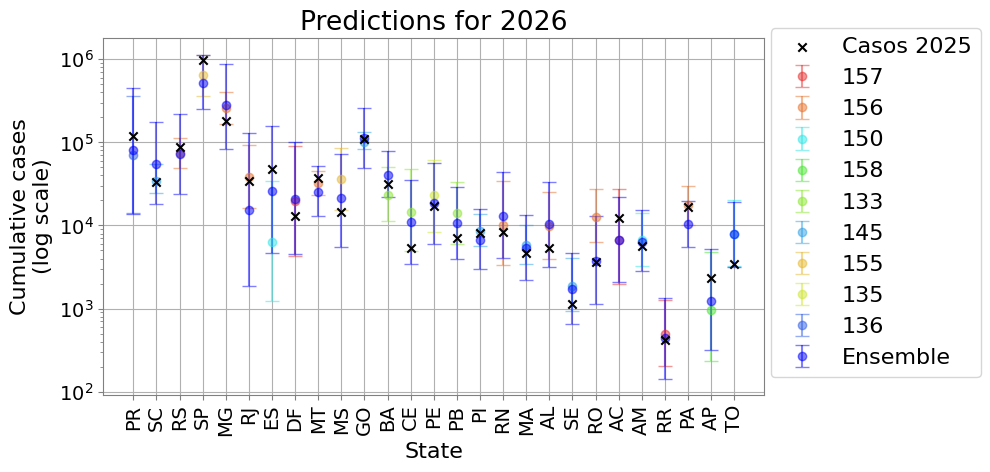

In [102]:
#obs = df_cum.casos.values[0]
_, ax = plt.subplots(figsize = (10.2, 5))

#ax.axhline(obs, color = 'black', linewidth =2, linestyle = '--', label = 'Data')
ax.scatter(df_d.state, df_d.casos, marker = 'x',color = 'black', label = 'Casos 2025', zorder = 3)

for state in df_best_st_model.state.unique():
        plot_by_region(ax, df_cum_best_models, state = state)

# método da cópula
x = df_cum_cop.state.astype(str)
y = df_cum_cop.pred
    
# compute symmetric errors from lower and upper bounds
yerr = np.array([y - df_cum_cop.lower_90, df_cum_cop.upper_90 - y])

for xi, yi, yierr, low, up in zip(x, y, yerr.T, df_cum_cop.lower_90, df_cum_cop.upper_90):
    # condition: observed is inside prediction interval

    ax.errorbar(xi, yi, yerr=yierr.reshape(2,1), fmt="o", 
                    color='blue', ecolor='blue', capsize=5, alpha = 0.5, label = 'Ensemble')
        
ax.set_ylabel('Cumulative cases\n(log scale)')
ax.set_xlabel('State')
    
ax.set_title(f'Predictions for 2026')

#    ax.set_ylim([0, max(2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 1)].casos.values[0],
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 2)].casos.values[0], 
#                        2*df_cum_cases.loc[(df_cum_cases.state == state) & (df_cum_cases.valid_test == 3)].casos.values[0])])
ax.set_yscale('log')
ax.grid()
for label in ax.get_xticklabels():
        label.set_rotation(90)

handles, labels = plt.gca().get_legend_handles_labels()

# Remove duplicates
unique = dict(zip(labels, handles))

plt.legend(unique.values(), unique.keys(), loc =(1.01,0.05))

plt.tight_layout()

plt.show()